In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

In [2]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2,random_state=23)

In [3]:
x.shape

(1000, 2)

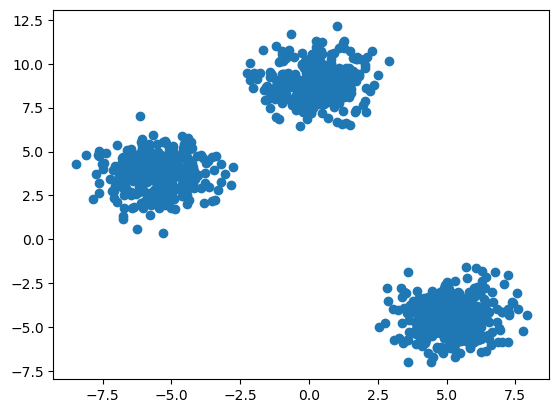

In [23]:
plt.scatter(x[:,0],x[:,1])
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [11]:
from sklearn.cluster import KMeans

In [13]:
wcss=[]
for k in range(1,11):
    kmeans=KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(x_train)
    wcss.append(kmeans.inertia_)

In [14]:
wcss

[41167.283407539,
 9544.87262319091,
 1570.3723999827841,
 1393.2605268912075,
 1208.199660416171,
 1023.4506441384187,
 928.7726971823502,
 809.914038618162,
 748.9865832926091,
 642.6929817138166]

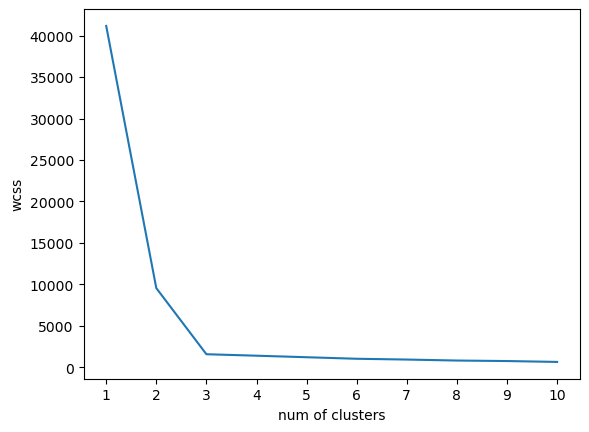

In [49]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("num of clusters")#this is manual method for finding clusters for small data if data is larger this will not helpful
plt.ylabel("wcss")
plt.savefig("elbow.png")
plt.show()

In [17]:
kmeans=KMeans(n_clusters=3,init="k-means++")

In [24]:
y_test_lables=kmeans.predict(x_test)

In [25]:
y_labels=kmeans.fit_predict(x_train)#fit_pretdict only for training data

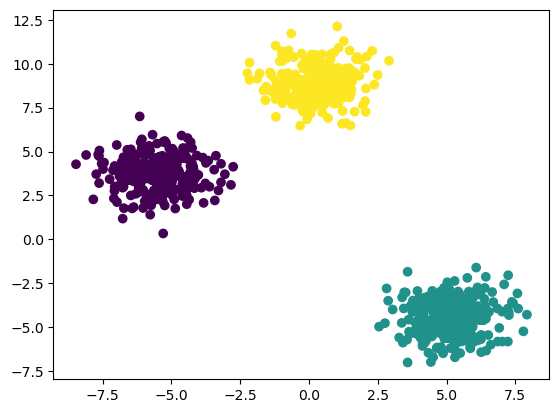

In [48]:
plt.scatter(x_train[:,0],x_train[:,1],c=y_labels)
plt.savefig("cluster_train.png")
plt.show()

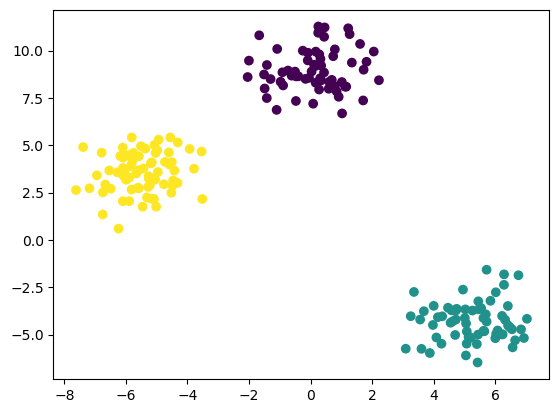

In [47]:
plt.scatter(x_test[:,0],x_test[:,1],c=y_test_lables)
plt.savefig("clusters_test.png")
plt.show()

In [31]:
#if data is very large then manual(elbow method will not work ) instrad we will use sklearn library called "knee locator"
#automatically find k value

In [32]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [33]:
from kneed import KneeLocator

In [35]:
kl=KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
kl.elbow

np.int64(3)

In [36]:
#performance matrics

In [37]:
from sklearn.metrics import silhouette_score

In [42]:
silhouette_coeff=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(x_train)
    score=silhouette_score(x_train,kmeans.labels_)
    silhouette_coeff.append(score)

In [43]:
silhouette_coeff

[0.7258310358179207,
 0.8068049253852778,
 0.6411258217169735,
 0.4825154731340928,
 0.32934327758283644,
 0.3242445086597667,
 0.32757766744690575,
 0.33580755547798036,
 0.3287583593745593]

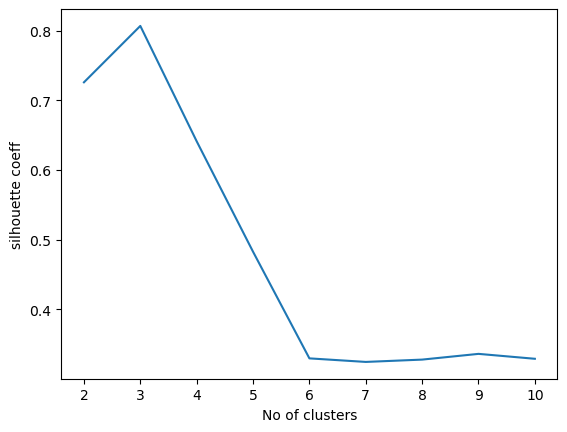

In [46]:
plt.plot(range(2,11),silhouette_coeff)
plt.xlabel("No of clusters")
plt.ylabel("silhouette coeff")
plt.savefig("silhoette.png")
plt.show()